In [1]:
import matplotlib.pyplot as plt
import nivapy3 as nivapy
import pandas as pd
import seaborn as sn
import utils

plt.style.use("ggplot")

# Colours for plots
COLOUR_DICT = {
    "Akvakultur": "royalblue",
    "Jordbruk": "sienna",
    "Avløp": "red",
    "Industri": "darkgrey",
    "Bebygd": "gold",
    "Bakgrunn": "limegreen",
    "Menneskeskapt": "pink",
    "Totalt": "black",
}
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=list(COLOUR_DICT.values()))

# Oslofjord Q trends

## 2. Elveovervåkingsprogrammet

### 2.1. Define monitoring stations around Oslofjord

5 of the Oslofjord's main rivers are monitored as part of Elveovervåkingsprogrammet. The total land area of the Oslofjord catchment is around 85 000 km2. The code below first estimates what proportion of this is covered by the monitoring.

In [2]:
stn_dict = {
    29612: ["Drammenselva", "012.A3"],
    36225: ["Alna", "006.2A0"],
    29613: ["Skienselva", "016.A222"],
    29615: ["Numedalslågen", "015.A1"],
    29617: ["Glomma", "002.A51"],
}

In [3]:
# Read observed
obs_path = r"/home/jovyan/shared/common/elveovervakingsprogrammet/results/measured_loads/loads_and_flows_rid_20_1990-2023.csv"
obs_df = pd.read_csv(obs_path)
obs_df["Mean_Flow_m3/s"] = obs_df["mean_q_1000m3/day"] * 1000 / (24*60*60)

In [4]:
df_list = []
for stn_id, (name, reg_id) in stn_dict.items():
    # Get observed data
    stn_par_df_obs = obs_df.query("(station_id == @stn_id)")[
        ["station_id", "year", "Mean_Flow_m3/s"]
    ].copy()
    stn_par_df_obs["name"] = name
    df_list.append(stn_par_df_obs)

elv_df = pd.concat(df_list, axis="rows")[
    ["station_id", "name", "year", "Mean_Flow_m3/s"]
]
elv_df.head()

,station_id,name,year,Mean_Flow_m3/s
34,29612,Drammenselva,1990,299.665910
35,29612,Drammenselva,1991,223.082389
36,29612,Drammenselva,1992,257.059042
37,29612,Drammenselva,1993,325.878339
38,29612,Drammenselva,1994,316.955393


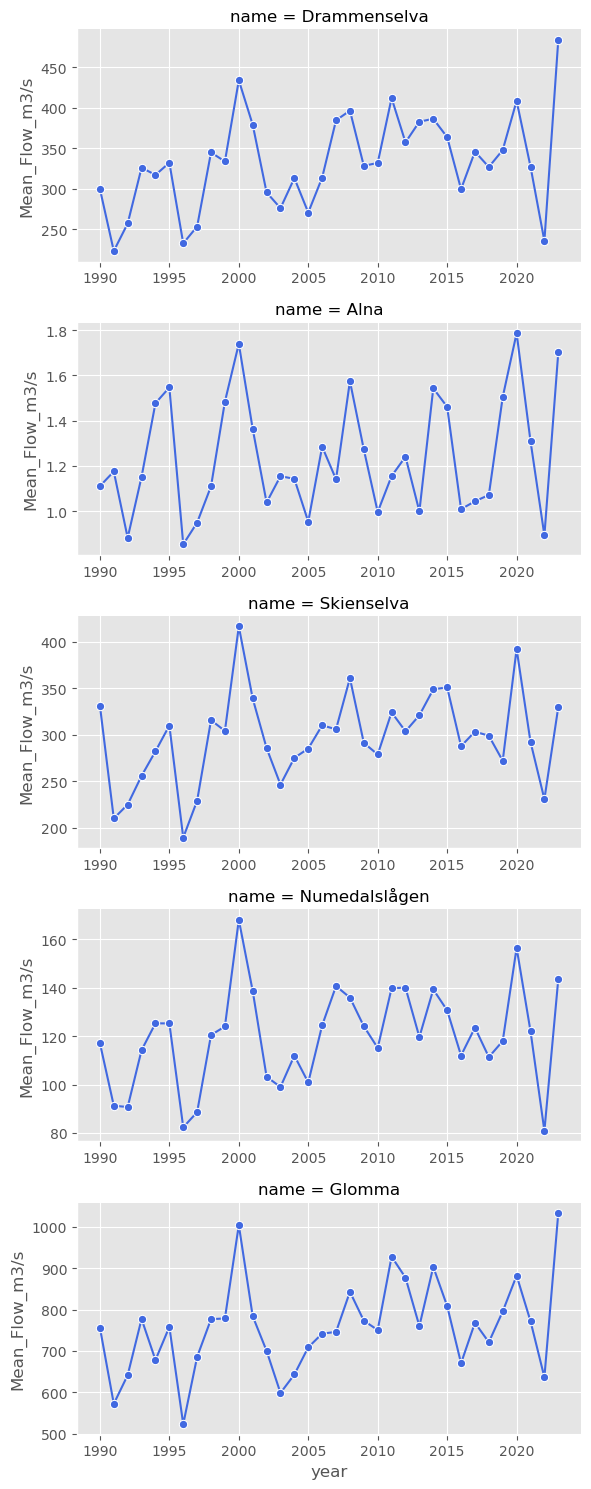

In [5]:
# Plot
sn.relplot(
    data=elv_df,
    x="year",
    y="Mean_Flow_m3/s",
    row="name",
    kind="line",
    marker="o",
    height=3,
    aspect=2,
    facet_kws={"sharey": "row", "sharex": False},
)
plt.savefig("monitored_q_rid_rivers_1990-2023.png", dpi=200, bbox_inches="tight")

In [6]:
# Test for trends
print("Observed trends for 1990 to 2023:")
for stn_id, (name, reg_id) in stn_dict.items():
    print(name)
    res_df = elv_df.query("(station_id == @stn_id)").copy()
    mk_df = nivapy.stats.mk_test(res_df, "Mean_Flow_m3/s", alpha=0.05)
    sen_res_df, sen_df = nivapy.stats.sens_slope(
        res_df, "Mean_Flow_m3/s", index_col="year", alpha=0.05
    )
    trend = mk_df.loc["trend", "value"]
    sslp = sen_res_df.loc['sslp', 'value']
    print(f"  Q: {trend} ({sslp:.1f} (m3/s)/year)")

Observed trends for 1990 to 2023:
Drammenselva
  Q: increasing (2.9 (m3/s)/year)
Alna
  Q: no trend (0.0 (m3/s)/year)
Skienselva
  Q: no trend (1.5 (m3/s)/year)
Numedalslågen
  Q: no trend (0.7 (m3/s)/year)
Glomma
  Q: increasing (4.4 (m3/s)/year)


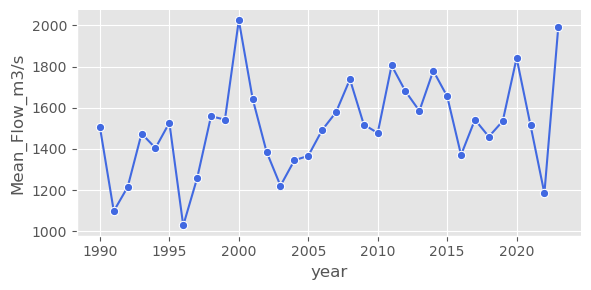

In [7]:
# Combine monitoring data for Oslofjord
osl_df = (
    elv_df.groupby(["year"])
    .sum(numeric_only=True)[["Mean_Flow_m3/s"]]
    .reset_index()
)

# Plot
sn.relplot(
    data=osl_df,
    x="year",
    y="Mean_Flow_m3/s",
    kind="line",
    marker="o",
    height=3,
    aspect=2,
    facet_kws={"sharey": "row", "sharex": False},
)
plt.savefig("monitored_q_oslofjord_1990-2023.png", dpi=200, bbox_inches="tight")

,description,value
sslp,Median slope estimate,10.340871
icpt,Estimated intercept,-19232.353278
lb,Lower bound on slope estimate at specified alpha,1.299309
ub,Upper bound on slope estimate at specified alpha,17.811279
trend,Type of trend (if present),increasing


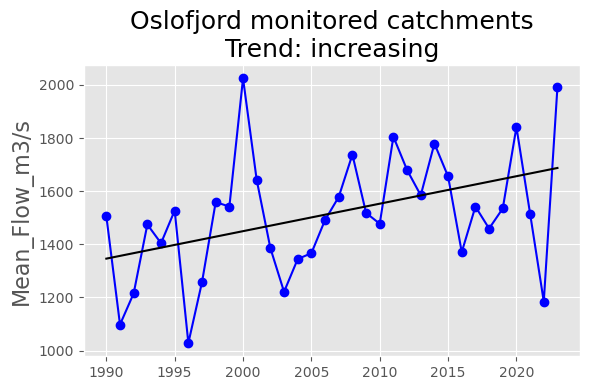

In [8]:
# Test for trends
mk_df = nivapy.stats.mk_test(osl_df, "Mean_Flow_m3/s", alpha=0.05)
res_df, sen_df = nivapy.stats.sens_slope(
    osl_df, "Mean_Flow_m3/s", index_col="year", alpha=0.05
)
trend = mk_df.loc["trend", "value"]
display(res_df)
nivapy.plotting.plot_sens_slope(
    res_df,
    sen_df,
    ylabel="Mean_Flow_m3/s",
    title=f"Oslofjord monitored catchments\nTrend: {trend}",
)
plt.savefig(
    f"monitored_q_trend_1990-2023.png",
    dpi=200,
    bbox_inches="tight",
)